In [17]:
import numpy as np
student_marks = np.array([
    [85, 90, 88, 75, 95],
    [78, 82, 84, 80, 89],
    [92, 88, 91, 87, 94],
    [76, 85, 83, 78, 88],
    [89, 87, 85, 90, 92]
])

#Retrieve Science , english and history columns across all rows 
data_1 = student_marks[: , [1,2,3]]
print(data_1)

#Retrieve score of the first and last student for subjects like science and history 
Retrieve_score_2 = student_marks[[0, 4], [1,3]]
print(f"\n {Retrieve_score_2}")

#Retrieve the score of all students across all subject 
Retrieve_score_3 = student_marks[:,:]
print(f"\n {Retrieve_score_3}")

#Dublicating the second  rows of the first columns 
student_marks_2 = student_marks[1:2, :].copy()


print(student_marks_2)

[[90 88 75]
 [82 84 80]
 [88 91 87]
 [85 83 78]
 [87 85 90]]

 [90 90]

 [[85 90 88 75 95]
 [78 82 84 80 89]
 [92 88 91 87 94]
 [76 85 83 78 88]
 [89 87 85 90 92]]
[[78 82 84 80 89]]


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score , train_test_split
import pandas as pd 

df = pd.DataFrame({
    'Feature_1': [2.3 , 1.8 , 3.1 , 2.6 , 1.2, 3.4],
    'Feature_2': [1.2 , 0.9 , 1.5 , 1.3, 0.8 , 1.6],
    'Label': [0, 0 , 1, 1, 0 , 1]
})


model_logistic = LogisticRegression()

X = df.drop(columns = 'Label')
y = df['Label']

scores_logistic = cross_val_score(model_logistic, X , y , cv = 2)
print(f"Scores for each fold {scores_logistic}")
print(f"Average accuracy {scores_logistic.mean()}")


Scores for each fold [0.33333333 0.33333333]
Average accuracy 0.3333333333333333


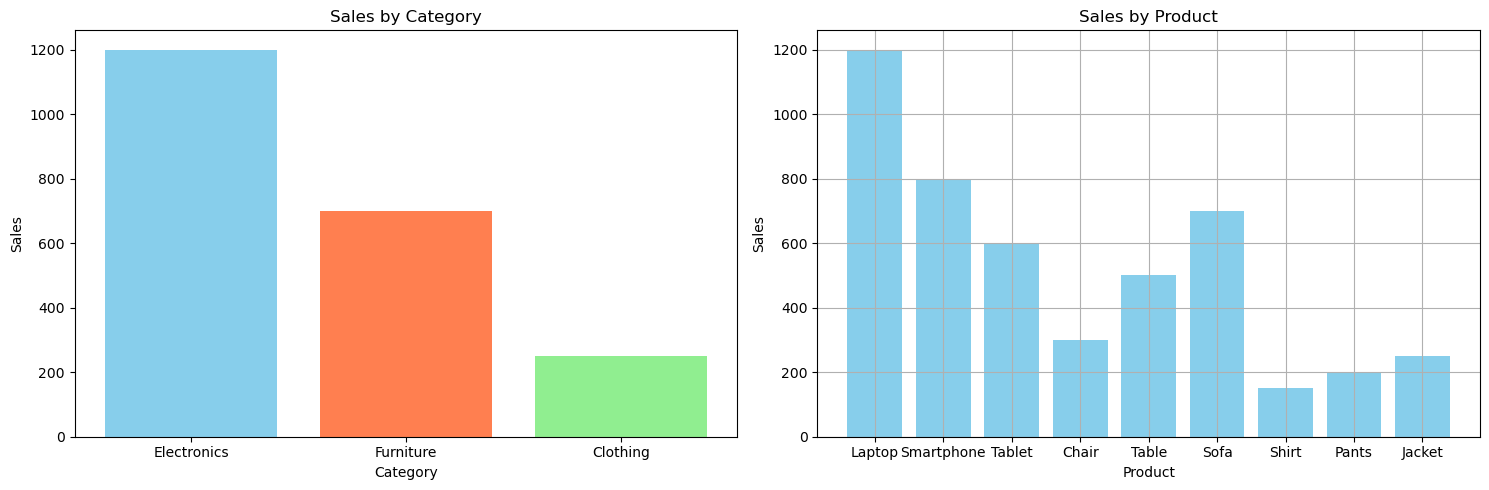

In [47]:

import matplotlib.pyplot as plt 
df_sales = pd.DataFrame({
    'Category': ['Electronics', 'Electronics', 'Electronics', 
                 'Furniture', 'Furniture', 'Furniture',
                 'Clothing', 'Clothing', 'Clothing'],
    'Product': ['Laptop', 'Smartphone', 'Tablet',
                'Chair', 'Table', 'Sofa',
                'Shirt', 'Pants', 'Jacket'],
    'Sales': [1200, 800, 600, 300, 500, 700, 150, 200, 250]
})
color_mapping_category = {
    'Electronics': 'skyblue', 
    'Furniture': 'coral', 
    'Clothing': 'lightgreen'
}

colors_Category = df_sales['Category'].map(color_mapping_category)

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))


axes[0].bar(df_sales['Category'], df_sales['Sales'], color = colors_Category)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Sales')
axes[0].set_title('Sales by Category')

axes[1].bar(df_sales['Product'], df_sales['Sales'], color = 'skyblue')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Sales')
axes[1].set_title('Sales by Product')
plt.grid()
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

df_students = pd.DataFrame({
    'Study_Hours': [2, 3, 1, 4, 2, 5, 1, 6, 3, 7, 2, 8, 4, 5, 3, 6, 4, 7, 5, 8, 3, 4, 2, 6, 5],
    'Attendance_%': [60, 70, 50, 80, 65, 85, 55, 90, 75, 95, 60, 92, 78, 88, 72, 89, 82, 93, 85, 96, 68, 80, 62, 87, 84],
    'Previous_Score': [45, 55, 40, 65, 50, 70, 42, 78, 60, 82, 48, 85, 68, 75, 58, 80, 72, 88, 76, 90, 52, 66, 47, 83, 77],
    'Pass': [0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1]
})
X_students = df_students.drop(columns = 'Pass')
y_students = df_students['Pass']
# X_train , y_train , X_test , y_test = train_test_split(X, y, random_state= 42 , test_size= 0.4)
DecistionTree = DecisionTreeClassifier()
params = {
    'max_depth': [None , 3 , 5],
    'min_samples_split': [2,5]
}
model_decision_tree = GridSearchCV(DecistionTree, params , cv = 3 , scoring = 'neg_mean_squared_error')
model_decision_tree.fit(X_students, y_students)
# model_decision_tree.fit(X_train , y_train)
# y_predict = model_decision_tree.predict(X_test)
# print(f"Best parameters {model_decision_tree.best_params_}")

# results = pd.DataFrame({
#     'Predicted value': y_predict,
#     'Actual Value': y_test
# })

In [ ]:
import seaborn as sns 
import pandas as pd


# Create DataFrame from the image
df_regional_sales = pd.DataFrame({
    'Year': [2021, 2021, 2021, 2021, 2022, 2022, 2022, 2022, 2023, 2023, 2023, 2023],
    'Region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West', 'North', 'South', 'East', 'West'],
    'Sales': [25000, 30000, 15000, 20000, 27000, 32000, 18000, 22000, 29000, 36000, 35000, 25000]
})
regional_facet_grid = sns.FacetGrid(df_regional_sales, col = 'Region', col_wrap= 4, height =4, aspect= 1.5)
regional_facet_grid.map(sns.barplot, 'Year', 'Sales', palette=['steelblue', 'darkblue', 'navy'])
regional_facet_grid.set_axis_labels('Year', 'Sales')
regional_facet_grid.set_titles('Sales in {col_name}')
plt.tight_layout()
plt.show()